# Step 01 — Data Ingestion

This notebook provides a visual overview of the raw macro data ingested by
`pipelines/01_ingest.py`. It loads `data/raw/macro_raw.parquet` and produces
coverage plots, sample time-series, and summary statistics.

**Run `python pipelines/01_ingest.py` before executing this notebook.**

## Setup & Imports

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "../src")
import logging
import pandas as pd
import matplotlib.pyplot as plt
from market_regime.config import load, setup_logging
from market_regime.runtime import RunConfig
from market_regime import DATA_DIR, plotting
setup_logging("INFO")
log = logging.getLogger("01_ingestion")
cfg = load()
run_cfg = RunConfig(generate_plots=True, save_plots=True, show_plots=False)

In [2]:
import subprocess
from pathlib import Path

def run_step_if_needed(step: int, required_paths: list, auto_run: bool = True) -> bool:
    """Run the pipeline step if any required output files are missing."""
    missing = [p for p in required_paths if not Path(p).exists()]
    if not missing:
        return True
    print(f"Missing: {[str(p) for p in missing]}")
    scripts = sorted(Path("../pipelines").glob(f"{step:02d}_*.py"))
    if not scripts:
        print(f"No pipeline script found for step {step}.")
        return False
    script = scripts[0]
    if not auto_run:
        print(f"  → Run: python {script}")
        return False
    print(f"  → Running {script.name} ...")
    result = subprocess.run(["python", str(script)], capture_output=True, text=True, cwd="..")
    out = result.stdout
    if len(out) > 4000:
        out = out[:2000] + "\n...\n" + out[-2000:]
    print(out)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
        return False
    print(f"  ✓ Step {step} complete.")
    return True

# Run ingestion step if raw data is missing
run_step_if_needed(1, [DATA_DIR / "raw" / "macro_raw.parquet"])

True

## Load Raw Macro Data

The raw dataset is produced by `pipelines/01_ingest.py`. It contains all
multpl.com series and FRED series, resampled to quarterly frequency and
aligned to a common date index.

In [3]:
RAW_PATH = DATA_DIR / "raw" / "macro_raw.parquet"

try:
    raw = pd.read_parquet(RAW_PATH)
    log.info("Loaded raw data: shape=%s", raw.shape)
except FileNotFoundError:
    print(f"ERROR: Raw data file not found at {RAW_PATH}")
    print("Run 'python pipelines/01_ingest.py' first.")
    raw = None
except Exception as exc:
    print(f"ERROR loading raw data: {exc}")
    raw = None

2026-03-10 15:28:36 | INFO     | 01_ingestion | Loaded raw data: shape=(305, 54)


## Shape, Date Range, and Column Names

In [4]:
if raw is not None:
    print(f"Shape:      {raw.shape[0]} quarters x {raw.shape[1]} series")
    print(f"Date range: {raw.index.min().date()} to {raw.index.max().date()}")
    print()
    print(f"Columns ({len(raw.columns)} total):")
    for col in sorted(raw.columns):
        print(f"  {col}")

Shape:      305 quarters x 54 series
Date range: 1950-03-31 to 2026-03-31

Columns (54 total):
  10yr_real_int
  10yr_ustreas
  1mo_ustreas
  1yr_ustreas
  20yr_real_int
  20yr_ustreas
  2yr_ustreas
  30yr_real_int
  30yr_ustreas
  3yr_ustreas
  5yr_real_int
  5yr_ustreas
  6mo_ustreas
  book
  cape_shiller
  cpi
  div_growth
  div_yield
  dividend
  earn
  earn_growth
  earn_yld
  fed_debt
  fred_aaa
  fred_baa
  fred_cpi
  fred_gdp
  fred_gnp
  fred_gs10
  fred_tb3ms
  gdp
  gdp_growth
  market_code
  price_book
  price_sales
  real_earn_growth
  real_gdp
  real_gdp_growth
  real_gdp_per_cap
  real_sales
  real_sales_growth
  sales
  sales_growth
  sp500
  sp500_adj
  sp500_pe
  us_avg_income
  us_home_prices
  us_infl
  us_med_income
  us_med_income_growth
  us_med_real_income
  us_pop
  us_pop_growth


## Raw Series Coverage Heatmap

Dark cells indicate that data is available for that quarter. Many multpl.com
series start in the 1950s–1960s; FRED series have varying start dates.
The gap-filling step in the feature pipeline handles interior NaNs.

2026-03-10 15:28:37 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/01_raw_coverage.png


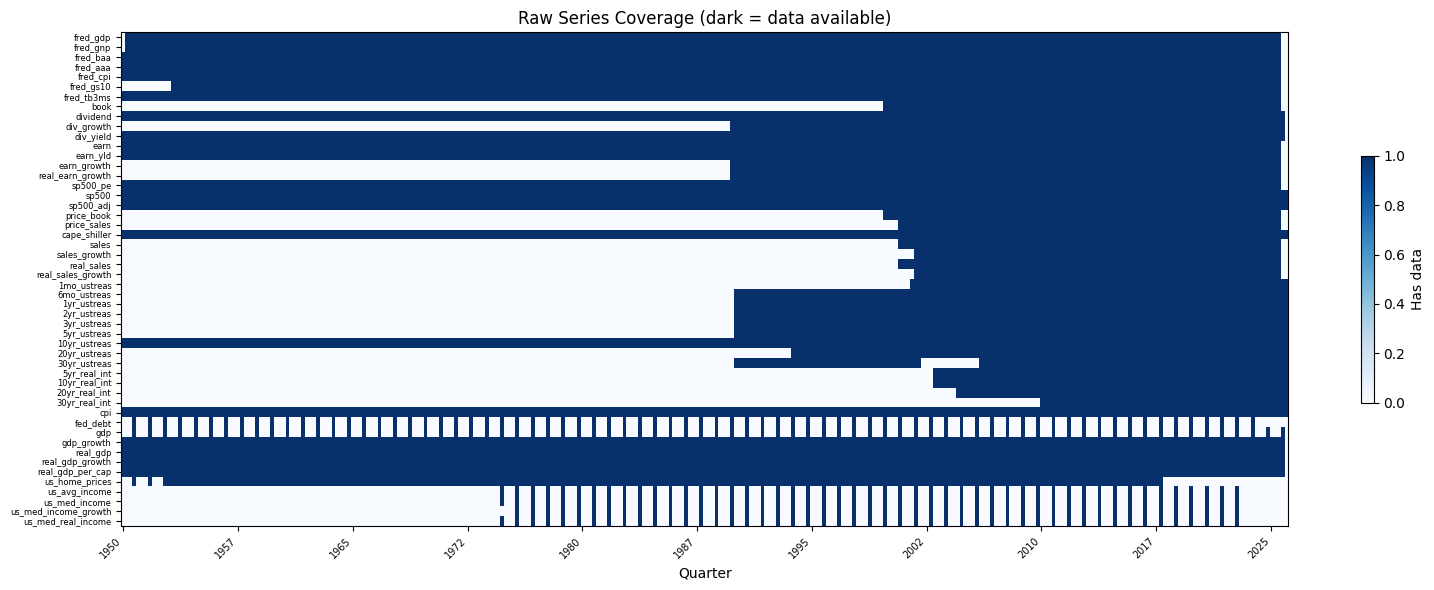

In [5]:
if raw is not None:
    plotting.plot_raw_series_coverage(raw, run_cfg)

## Sample Series Time Charts

A handful of key series — S&P 500, US inflation, 10-year Treasuries, nominal
GDP, and dividend yield — for a quick visual sanity check of the ingested data.

2026-03-10 15:28:39 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/01_raw_series_sample.png


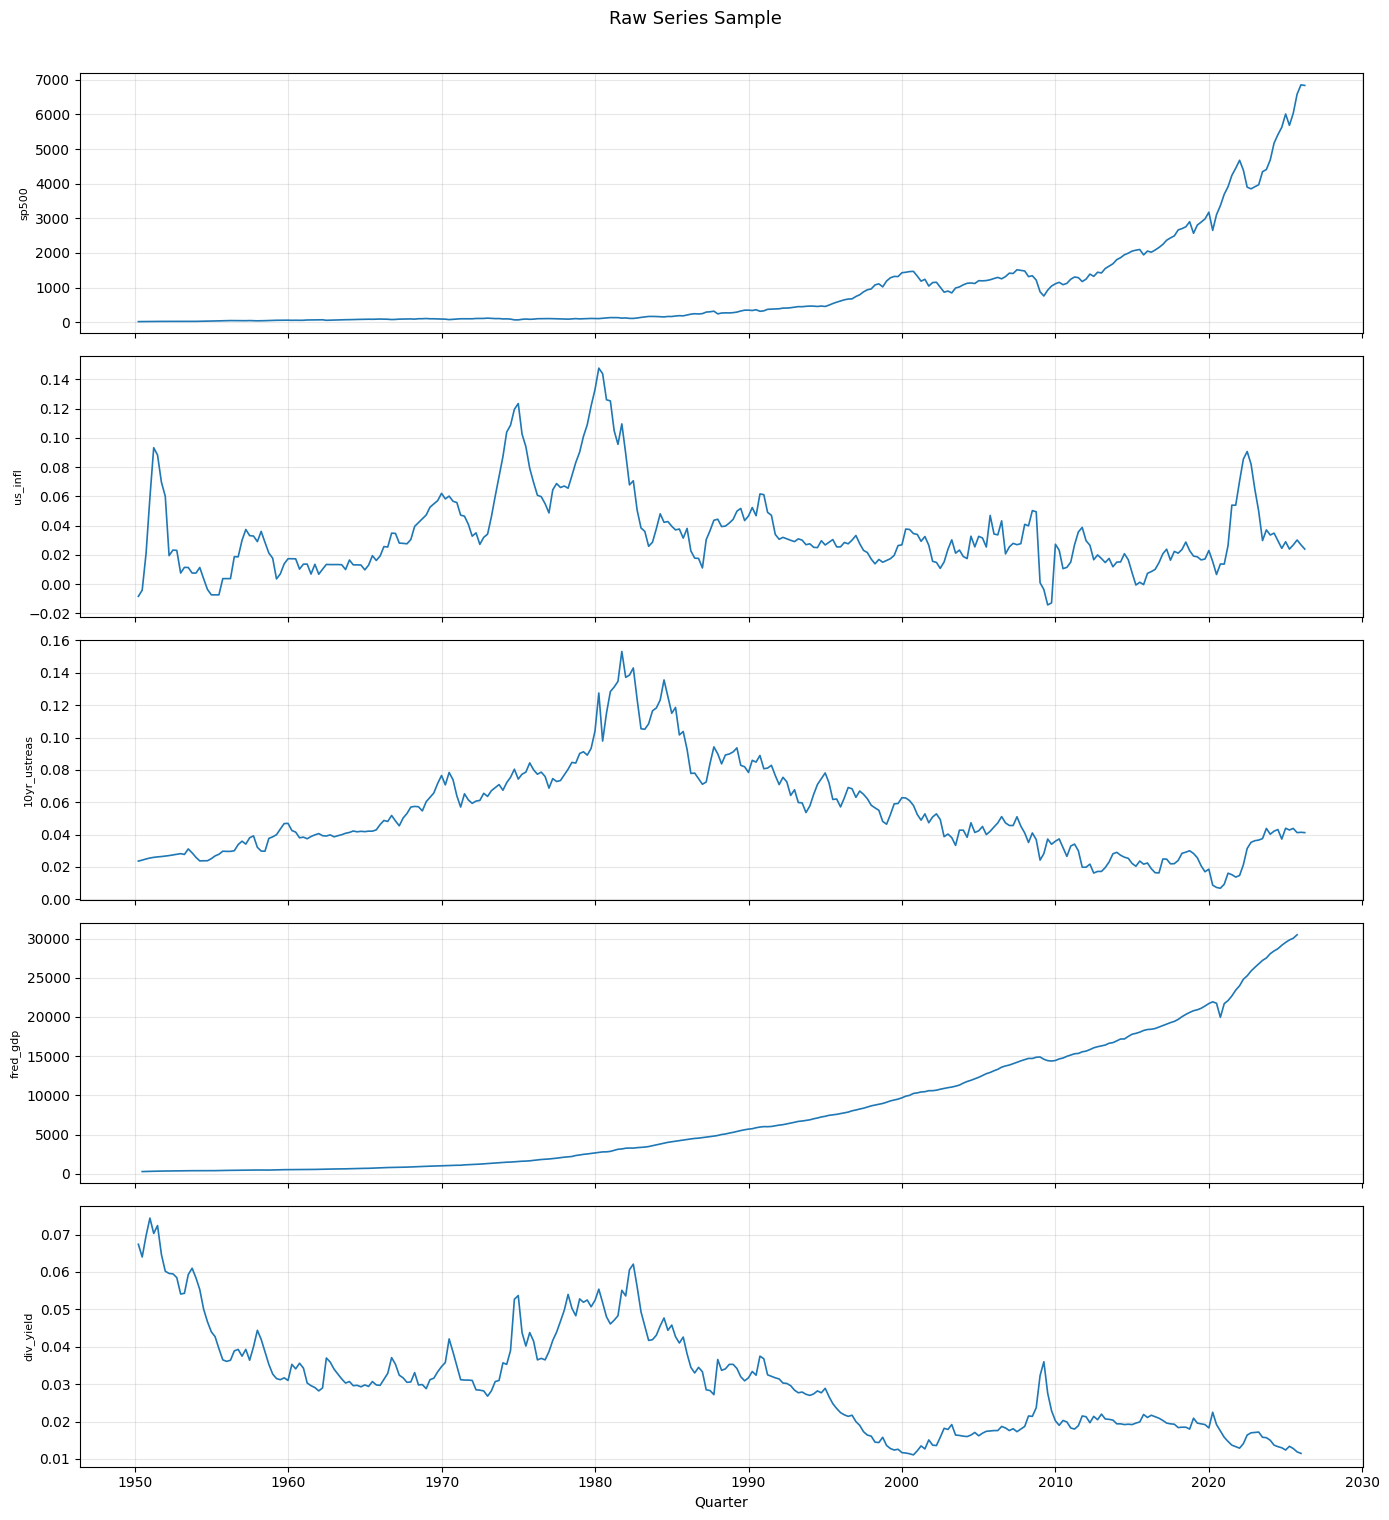

In [6]:
if raw is not None:
    SAMPLE_SERIES = ["sp500", "us_infl", "10yr_ustreas", "fred_gdp", "div_yield"]
    available = [s for s in SAMPLE_SERIES if s in raw.columns]
    missing   = [s for s in SAMPLE_SERIES if s not in raw.columns]
    if missing:
        print(f"Note: series not found in raw data: {missing}")
    if available:
        plotting.plot_raw_series_sample(raw, available, run_cfg)
    else:
        print("None of the requested sample series are present.")

## Coverage Statistics

Percentage of non-NaN observations per series, sorted descending.
Series with low coverage may introduce gaps that need to be filled
in the feature engineering step.

In [7]:
if raw is not None:
    coverage_pct = raw.notna().mean().sort_values(ascending=False) * 100
    coverage_df = coverage_pct.rename("coverage_pct").to_frame()
    coverage_df["n_valid"] = raw.notna().sum()
    coverage_df["n_total"] = len(raw)
    print(f"Total quarters: {len(raw)}")
    print()
    display(coverage_df.style.format({"coverage_pct": "{:.1f}%"}))

Total quarters: 305



,coverage_pct,n_valid,n_total
cape_shiller,100.0%,305,305
sp500,100.0%,305,305
sp500_adj,100.0%,305,305
us_infl,100.0%,305,305
cpi,100.0%,305,305
10yr_ustreas,100.0%,305,305
real_gdp_per_cap,99.7%,304,305
real_gdp,99.7%,304,305
real_gdp_growth,99.7%,304,305
gdp_growth,99.7%,304,305


## First and Last 5 Rows

In [8]:
if raw is not None:
    print("=== First 5 rows ===")
    display(raw.head())

=== First 5 rows ===


,fred_gdp,fred_gnp,fred_baa,fred_aaa,fred_cpi,fred_gs10,fred_tb3ms,book,dividend,div_growth,...,real_gdp_per_cap,us_home_prices,us_avg_income,us_med_income,us_med_income_growth,us_med_real_income,us_infl,us_pop,us_pop_growth,market_code
date,,,,,,,,,,,,,,,,,,,,,
1950-03-31,NaN,NaN,3.24,2.58,23.64,NaN,1.12,NaN,16.12,NaN,...,15512.08,NaN,NaN,NaN,NaN,NaN,-0.0084,NaN,NaN,1.0
1950-06-30,280.828,282.056,3.28,2.62,23.88,NaN,1.15,NaN,16.40,NaN,...,15904.29,NaN,NaN,NaN,NaN,NaN,-0.0042,NaN,NaN,1.0
1950-09-30,290.383,291.699,3.21,2.64,24.34,NaN,1.30,NaN,17.73,NaN,...,16444.21,NaN,NaN,NaN,NaN,NaN,0.0209,152.27,0.0207,1.0
1950-12-31,308.153,309.760,3.20,2.67,24.98,NaN,1.34,NaN,19.12,NaN,...,16687.90,155.56,NaN,NaN,NaN,NaN,0.0593,NaN,NaN,1.0
1951-03-31,319.945,321.554,3.23,2.78,25.88,NaN,1.40,NaN,19.16,NaN,...,16842.95,NaN,NaN,NaN,NaN,NaN,0.0932,NaN,NaN,1.0


In [9]:
if raw is not None:
    print("=== Last 5 rows ===")
    display(raw.tail())

=== Last 5 rows ===


,fred_gdp,fred_gnp,fred_baa,fred_aaa,fred_cpi,fred_gs10,fred_tb3ms,book,dividend,div_growth,...,real_gdp_per_cap,us_home_prices,us_avg_income,us_med_income,us_med_income_growth,us_med_real_income,us_infl,us_pop,us_pop_growth,market_code
date,,,,,,,,,,,,,,,,,,,,,
2025-03-31,29825.182,29864.292,5.93,5.29,319.785,4.28,4.20,1197.11,77.44,0.0751,...,68972.63,NaN,NaN,NaN,NaN,NaN,0.0239,341.41,0.0071,0.0
2025-06-30,30042.113,30044.191,6.15,5.46,321.435,4.38,4.23,1238.93,77.99,0.0746,...,69532.35,NaN,NaN,NaN,NaN,NaN,0.0267,341.87,0.0060,0.0
2025-09-30,30485.729,30467.351,5.83,5.21,324.245,4.12,3.92,1270.32,78.59,0.0692,...,70170.52,NaN,NaN,NaN,NaN,NaN,0.0301,342.41,0.0056,1.0
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.21,0.0546,...,70314.81,NaN,NaN,NaN,NaN,NaN,0.0268,342.91,0.0056,0.0
2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0239,NaN,NaN,NaN
